**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 3 - Atividade: Regressão Logística (Student Exam Performance)**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Logística com PyTorch — Student Exam Performance Prediction


## Objetivos


Este notebook aplica a **regressão logística** à classificação binária do desempenho de estudantes, utilizando o dataset *Student Exam Performance Prediction* (Kaggle, `mrsimple07`). A estrutura adapta o notebook de regressão logística para o conjunto Íris, mantendo os conceitos centrais:

- a rede é uma única camada densa linear (`nn.Linear`), seguida da função *softmax*;
- a função de perda é a **Entropia Cruzada** (`CrossEntropyLoss`);
- a otimização é realizada por gradiente descendente (`SGD`).

**Descrição do problema.** A partir de dois atributos — número de horas de estudo (`Study Hours`) e nota no exame anterior (`Previous Exam Score`) —, deseja-se prever se o estudante será **aprovado** (1) ou **reprovado** (0) no exame final. Trata-se, portanto, de um problema de classificação binária com duas variáveis de entrada, o que possibilita, adicionalmente, a visualização da fronteira de decisão em um plano bidimensional, à semelhança do notebook original.

## Importação das bibliotecas


In [4]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

# Semente para reprodutibilidade
torch.manual_seed(1234)
np.random.seed(1234)

## Dataset: leitura, exploração e visualização


O dataset é carregado a partir do arquivo `student_exam_data.csv`. Caso o notebook seja executado no Google Colab, o arquivo deve ser previamente enviado ao ambiente (por exemplo, via `files.upload()` ou montagem do Google Drive). O conjunto possui 500 registros e três colunas: as duas variáveis preditoras e a variável-alvo `Pass/Fail`.

In [5]:
# Download do dataset diretamente do Kaggle (API pública)
!curl -L -o /content/student-exam.zip https://www.kaggle.com/api/v1/datasets/download/mrsimple07/student-exam-performance-prediction
!unzip -o /content/student-exam.zip -d /content/student-exam

# Leitura do arquivo principal
df = pd.read_csv('/content/student-exam/student_exam_data.csv')

print('Dimensões do dataset:', df.shape)
print('Valores ausentes:', df.isnull().sum().sum())
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19784  100 19784    0     0  85894      0 --:--:-- --:--:-- --:--:-- 85894
Archive:  /content/student-exam.zip
  inflating: /content/student-exam/student_exam_data.csv  
  inflating: /content/student-exam/student_exam_data_new.csv  
Dimensões do dataset: (500, 3)
Valores ausentes: 0


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [6]:
# Estatísticas descritivas
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


### Distribuição das classes

Antes de modelar, verifica-se o balanceamento entre as classes, informação relevante para a interpretação da acurácia.

Reprovados (0): 316
Aprovados  (1): 184
Proporção de aprovados: 36.8%


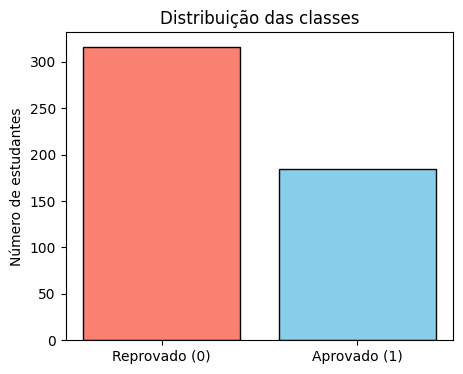

In [7]:
contagem = df['Pass/Fail'].value_counts().sort_index()
print('Reprovados (0):', contagem[0])
print('Aprovados  (1):', contagem[1])
print('Proporção de aprovados: {:.1%}'.format(contagem[1] / contagem.sum()))

plt.figure(figsize=(5, 4))
plt.bar(['Reprovado (0)', 'Aprovado (1)'], contagem.values, color=['salmon', 'skyblue'], edgecolor='k')
plt.ylabel('Número de estudantes')
plt.title('Distribuição das classes')
plt.show()

### Visualização dos dados

A dispersão das amostras no plano das duas variáveis preditoras permite uma inspeção visual da separabilidade das classes.

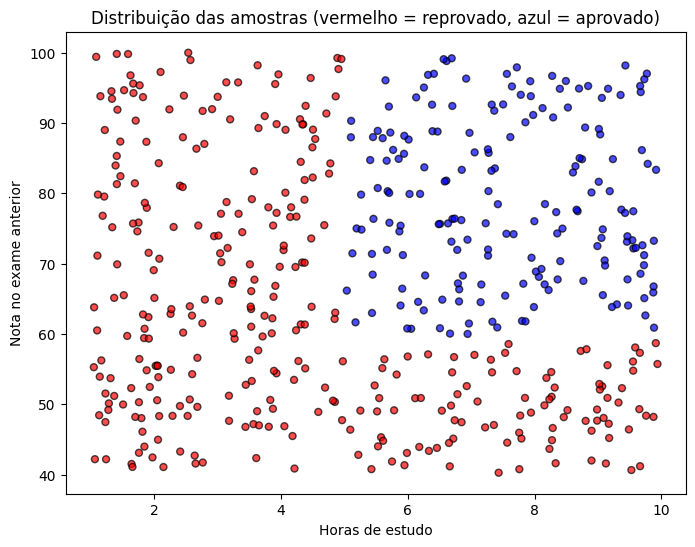

In [8]:
colors = np.array(['red', 'blue'])
plt.figure(figsize=(8, 6))
plt.scatter(df['Study Hours'], df['Previous Exam Score'],
            c=colors[df['Pass/Fail'].values], edgecolors='k', s=25, alpha=0.7)
plt.xlabel('Horas de estudo')
plt.ylabel('Nota no exame anterior')
plt.title('Distribuição das amostras (vermelho = reprovado, azul = aprovado)')
plt.show()

### Normalização e preparação dos dados para o PyTorch


As variáveis preditoras são normalizadas para o intervalo $[0, 1]$ (normalização *min-max*), procedimento idêntico ao adotado no notebook original e importante para o bom condicionamento do gradiente descendente. Em seguida, o conjunto é dividido em treinamento (80%) e teste (20%), preservando a proporção das classes (`stratify`). Por fim, os dados são convertidos para tensores: as entradas como `FloatTensor` e os rótulos como `LongTensor`, conforme exigido pela função de perda `CrossEntropyLoss`.

In [9]:
X = df[['Study Hours', 'Previous Exam Score']].values.astype(np.float32)
Y = df['Pass/Fail'].values.astype(np.int64)

# Normalização min-max
Xc = X - X.min(axis=0)
Xc = Xc / Xc.max(axis=0)

# Divisão treino/teste (estratificada)
X_train, X_test, Y_train, Y_test = train_test_split(
    Xc, Y, test_size=0.2, random_state=42, stratify=Y)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)

# Conversão para tensores
X_train_tensor = torch.FloatTensor(X_train)
Y_train_tensor = torch.LongTensor(Y_train)
X_test_tensor = torch.FloatTensor(X_test)
Y_test_tensor = torch.LongTensor(Y_test)

Treino: (400, 2) | Teste: (100, 2)


## Construindo o modelo da rede


O modelo é uma camada densa linear com **2 entradas** (as duas variáveis preditoras) e **2 saídas** (uma para cada classe: reprovado e aprovado). As saídas correspondem aos *scores* (logitos), que são posteriormente convertidos em probabilidades pela função *softmax*.

Cabe observar que, em classificação binária, é possível empregar alternativamente uma única saída com a função sigmoide e a perda `BCEWithLogitsLoss`. Optou-se, contudo, por manter a formulação com duas saídas e `CrossEntropyLoss`, por fidelidade ao notebook de referência e por sua generalização natural a problemas multiclasse.

In [10]:
model = nn.Linear(2, 2)  # 2 entradas e 2 saídas (2 classes)

In [11]:
# Inspeção dos parâmetros inicializados
model.state_dict()

OrderedDict([('weight',
              tensor([[-0.6661, -0.1387],
                      [-0.3396, -0.1886]])),
             ('bias', tensor([-0.6247,  0.2838]))])

### Demonstração de uma predição (predict)


A título de ilustração, calcula-se a saída do modelo (ainda não treinado) para as quatro primeiras amostras e converte-se essa saída em probabilidades por meio da função *softmax*.

In [12]:
out = model(Variable(X_train_tensor[:4, :]))
print('Scores (logitos):')
print(out)
print('\nProbabilidades (softmax):')
print(F.softmax(out, dim=1))

Scores (logitos):
tensor([[-1.1256, -0.0416],
        [-0.9905,  0.0059],
        [-0.7406,  0.1810],
        [-0.9692,  0.1007]], grad_fn=<AddmmBackward0>)

Probabilidades (softmax):
tensor([[0.2528, 0.7472],
        [0.2697, 0.7303],
        [0.2846, 0.7154],
        [0.2554, 0.7446]], grad_fn=<SoftmaxBackward0>)


In [13]:
# Predição da classe: índice da maior probabilidade
prob, y_pred = torch.max(F.softmax(out, dim=1), dim=1)
print('Classe prevista:', y_pred)
print('Probabilidade:  ', prob)

Classe prevista: tensor([1, 1, 1, 1])
Probabilidade:   tensor([0.7472, 0.7303, 0.7154, 0.7446], grad_fn=<MaxBackward0>)


## Treinamento


### Definição da função de perda e do otimizador


In [14]:
lr = 0.15
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

### Laço de treinamento

A cada época, acompanha-se a perda nos conjuntos de treinamento e de teste, o que permite verificar a convergência e detectar eventual sobreajuste (*overfitting*).

In [15]:
nb_epoch = 5000

train_losses = []
test_losses = []

for epoch in range(nb_epoch):
    # ---- treinamento ----
    model.train()
    output = model(Variable(X_train_tensor))
    loss = criterion(output, Variable(Y_train_tensor))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # ---- avaliação no conjunto de teste ----
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_tensor), Y_test_tensor)
    test_losses.append(test_loss.item())

    if (epoch + 1) % 500 == 0:
        print(f'Época [{epoch+1}/{nb_epoch}], '
              f'Perda treino: {loss.item():.4f}, Perda teste: {test_loss.item():.4f}')

print('\nPerda final de treino:', train_losses[-1])

Época [500/5000], Perda treino: 0.3607, Perda teste: 0.3422
Época [1000/5000], Perda treino: 0.3156, Perda teste: 0.2916
Época [1500/5000], Perda treino: 0.2988, Perda teste: 0.2727
Época [2000/5000], Perda treino: 0.2904, Perda teste: 0.2632
Época [2500/5000], Perda treino: 0.2855, Perda teste: 0.2577
Época [3000/5000], Perda treino: 0.2825, Perda teste: 0.2543
Época [3500/5000], Perda treino: 0.2805, Perda teste: 0.2520
Época [4000/5000], Perda treino: 0.2792, Perda teste: 0.2504
Época [4500/5000], Perda treino: 0.2782, Perda teste: 0.2493
Época [5000/5000], Perda treino: 0.2775, Perda teste: 0.2485

Perda final de treino: 0.27751877903938293


### Evolução da perda


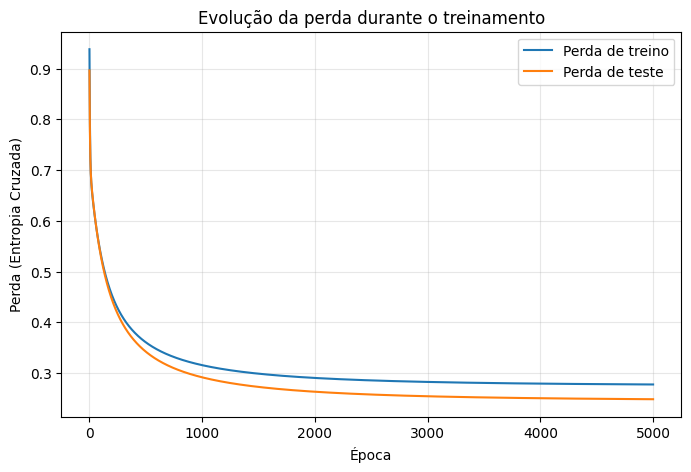

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Perda de treino')
plt.plot(test_losses, label='Perda de teste')
plt.xlabel('Época')
plt.ylabel('Perda (Entropia Cruzada)')
plt.title('Evolução da perda durante o treinamento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Avaliação


### Parâmetros após o treinamento


In [17]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.8538, -3.9102],
                      [ 3.8480,  3.5829]])),
             ('bias', tensor([ 4.4798, -4.8207]))])

### Funções de predição


In [18]:
def predict(model, inputs):
    """Retorna a classe prevista (índice de maior score)."""
    with torch.no_grad():
        outputs = model(Variable(inputs))
        _, predicts = torch.max(outputs, 1)
    return predicts.numpy()

def predict_prob(model, inputs):
    """Retorna a probabilidade da classe mais provável."""
    with torch.no_grad():
        outputs = F.softmax(model(Variable(inputs)), dim=1)
        probs, _ = torch.max(outputs, 1)
    return probs.numpy()

### Acurácia do classificador


A acurácia corresponde à proporção de classificações corretas em relação ao total de amostras. Reporta-se a acurácia tanto no conjunto de treinamento quanto no de teste; a proximidade entre ambas indica boa capacidade de generalização.

In [19]:
Y_pred_train = predict(model, X_train_tensor)
Y_pred_test = predict(model, X_test_tensor)

acc_train = (Y_pred_train == Y_train).mean()
acc_test = (Y_pred_test == Y_test).mean()

print('Acurácia de treino: {:.4f}'.format(acc_train))
print('Acurácia de teste:  {:.4f}'.format(acc_test))

Acurácia de treino: 0.8700
Acurácia de teste:  0.8700


### Matriz de confusão


A matriz de confusão detalha os acertos e erros por classe. Os elementos da diagonal principal representam as classificações corretas; os demais, os erros.

In [20]:
Y_pred_test = predict(model, X_test_tensor)
matriz = pd.crosstab(Y_pred_test, Y_test,
                     rownames=['Predito'], colnames=['Real'])
print('Matriz de confusão (conjunto de teste):')
matriz

Matriz de confusão (conjunto de teste):


Real,0,1
Predito,,
0,56,6
1,7,31


In [21]:
# Acurácia calculada a partir da matriz de confusão
cm = pd.crosstab(Y_pred_test, Y_test).values
acuracia_matriz = np.trace(cm) / cm.sum()
print('Acurácia a partir da matriz (soma da diagonal / total): {:.4f}'.format(acuracia_matriz))

Acurácia a partir da matriz (soma da diagonal / total): 0.8700


### Fronteira de decisão e mapa de probabilidades


Por se tratar de um problema com apenas duas variáveis de entrada, é possível visualizar a fronteira de decisão aprendida pelo modelo, bem como o mapa de probabilidade da classe mais provável em cada ponto do plano.

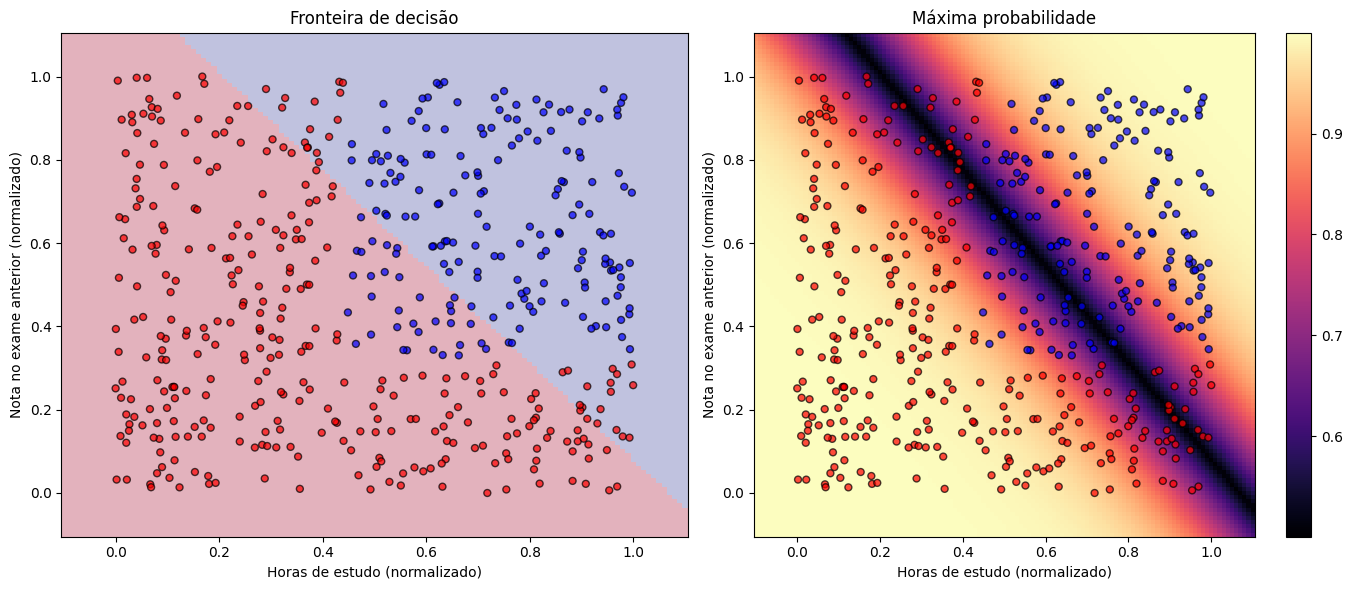

In [22]:
h = 0.01
x_min, x_max = Xc[:, 0].min() - 0.1, Xc[:, 0].max() + 0.1
y_min, y_max = Xc[:, 1].min() - 0.1, Xc[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

Zc = predict(model, torch.FloatTensor(grid)).reshape(xx.shape)
Zp = predict_prob(model, torch.FloatTensor(grid)).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = np.array(['red', 'blue'])

# Fronteira de decisão
ax1.pcolormesh(xx, yy, Zc, cmap=plt.cm.RdYlBu, alpha=0.3)
ax1.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y], edgecolors='k', s=25, alpha=0.7)
ax1.set_xlabel('Horas de estudo (normalizado)')
ax1.set_ylabel('Nota no exame anterior (normalizado)')
ax1.set_title('Fronteira de decisão')

# Mapa de probabilidades
pc = ax2.pcolormesh(xx, yy, Zp, cmap=plt.cm.magma)
ax2.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y], edgecolors='k', s=25, alpha=0.7)
ax2.set_xlabel('Horas de estudo (normalizado)')
ax2.set_ylabel('Nota no exame anterior (normalizado)')
ax2.set_title('Máxima probabilidade')
fig.colorbar(pc, ax=ax2)

plt.tight_layout()
plt.show()

### Salvamento e recuperação dos parâmetros treinados


À semelhança do notebook original, os parâmetros treinados podem ser salvos em disco e posteriormente recarregados, permitindo reutilizar o modelo sem a necessidade de novo treinamento.

In [23]:
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/RegrLog_StudentExam.pt')
print('Modelo salvo em models/RegrLog_StudentExam.pt')

Modelo salvo em models/RegrLog_StudentExam.pt


In [24]:
# Recuperação dos parâmetros salvos
param_saved = torch.load('models/RegrLog_StudentExam.pt')
model.load_state_dict(param_saved)
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.8538, -3.9102],
                      [ 3.8480,  3.5829]])),
             ('bias', tensor([ 4.4798, -4.8207]))])

## Questões conceituais


Reaproveitando as perguntas do notebook de referência, respondem-se a seguir as questões aplicáveis a este modelo.

**1. Como reiniciar o treinamento a partir do zero?**

Após o treinamento, executar novamente a célula do laço continua a otimização a partir dos parâmetros já ajustados, pois o objeto `model` mantém seu estado. Para reiniciar do zero, é necessário **reinstanciar o modelo** (`model = nn.Linear(2, 2)`) e **recriar o otimizador** (`optimizer = torch.optim.SGD(...)`), de modo que os pesos voltem à inicialização aleatória. Alternativamente, pode-se reinicializar explicitamente os parâmetros (por exemplo, com `nn.init`).

**2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?**

A camada `nn.Linear(2, 2)` possui uma matriz de pesos de formato `(2, 2)`, totalizando 4 parâmetros, e um vetor de *bias* com 2 elementos. O total é, portanto, **6 parâmetros** (4 de pesos e 2 de bias).

**3. Quantas entradas e quantas saídas esta rede possui?**

A rede possui **2 entradas** (horas de estudo e nota anterior) e **2 saídas** (os escores das classes reprovado e aprovado).

**4. Como se pode calcular a acurácia a partir da matriz de confusão?**

A acurácia é obtida pela razão entre a soma dos elementos da **diagonal principal** (classificações corretas) e a soma de todos os elementos da matriz (total de amostras). No caso binário, equivale a $(VP + VN) / (VP + VN + FP + FN)$. Esse cálculo foi demonstrado na célula correspondente, cujo resultado coincide com a acurácia de teste reportada.

**5. O que faz a função `torch.max`? Quantos valores retorna e quais seus significados?**

Quando aplicada com a especificação de uma dimensão — por exemplo, `torch.max(outputs, 1)` —, a função retorna **dois tensores**: o primeiro contém os valores máximos ao longo daquela dimensão, e o segundo, os índices em que tais máximos ocorrem. Na classificação, o segundo tensor (os índices) corresponde justamente à classe prevista para cada amostra, razão pela qual se utiliza a forma `_, predicts = torch.max(outputs, 1)`.

## Experimento complementar — efeito da taxa de aprendizado

Em atenção à segunda pergunta do notebook de referência ("experimente refazer o treinamento com diferentes valores de *learning rate*"), compara-se a convergência da perda para distintas taxas de aprendizado. Para cada valor, o modelo é reinstanciado, garantindo que o treinamento parta sempre da mesma condição inicial.

lr=0.01: perda final=0.3975, acurácia teste=0.9100
lr=0.05: perda final=0.2954, acurácia teste=0.8800
lr=0.15: perda final=0.2775, acurácia teste=0.8700
lr=0.5: perda final=0.2754, acurácia teste=0.8700
lr=1.0: perda final=0.2754, acurácia teste=0.8700


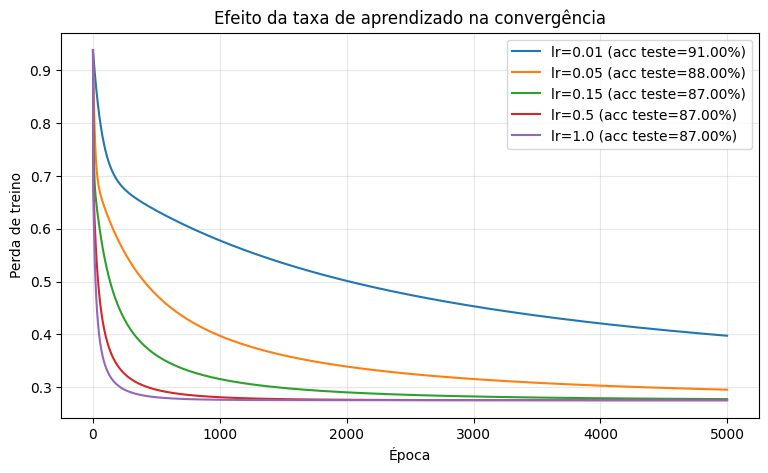

In [25]:
def treinar_lr(lr, nb_epoch=5000, seed=1234):
    torch.manual_seed(seed)
    m = nn.Linear(2, 2)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    perdas = []
    for _ in range(nb_epoch):
        out = m(X_train_tensor)
        loss = crit(out, Y_train_tensor)
        opt.zero_grad()
        loss.backward()
        opt.step()
        perdas.append(loss.item())
    acc = (predict(m, X_test_tensor) == Y_test).mean()
    return perdas, acc

plt.figure(figsize=(9, 5))
for lr_teste in [0.01, 0.05, 0.15, 0.5, 1.0]:
    perdas, acc = treinar_lr(lr_teste)
    plt.plot(perdas, label=f'lr={lr_teste} (acc teste={acc:.2%})')
    print(f'lr={lr_teste}: perda final={perdas[-1]:.4f}, acurácia teste={acc:.4f}')

plt.xlabel('Época')
plt.ylabel('Perda de treino')
plt.title('Efeito da taxa de aprendizado na convergência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Considerações finais


Este notebook aplicou a regressão logística, implementada em PyTorch, à predição do desempenho de estudantes (aprovação ou reprovação) a partir das horas de estudo e da nota no exame anterior. A metodologia reproduziu a do notebook de referência — camada linear, *softmax*, entropia cruzada e gradiente descendente —, adaptada de um problema de três classes (Íris) para um problema de classificação binária.

Os principais resultados e observações foram:

- O modelo alcançou acurácia em torno de **87%** nos conjuntos de treinamento e de teste, com valores próximos entre si, o que indica boa generalização e ausência de sobreajuste significativo.
- A visualização da fronteira de decisão evidenciou um comportamento coerente com a intuição do problema: estudantes com mais horas de estudo e melhores notas anteriores tendem a ser classificados como aprovados, e a separação entre as classes é aproximadamente linear.
- O experimento com diferentes taxas de aprendizado ilustrou seu efeito sobre a velocidade de convergência: valores muito baixos tornam o treinamento lento, enquanto valores adequados conduzem a uma convergência rápida e estável.

Como possíveis aprimoramentos, destacam-se a inclusão de mais variáveis preditoras (caso disponíveis), a padronização por média e desvio-padrão como alternativa à normalização *min-max*, e a adoção de modelos não lineares — etapa natural rumo às redes neurais de maior profundidade tratadas na disciplina.